<a href="https://colab.research.google.com/github/anushis9697/Advanced-SQL/blob/main/Data_Cleaning_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Load Dataset
df=pd.read_csv("/content/healthcare_data_cleaning_dataset.csv")


In [5]:
#Basic Info
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient_ID          5100 non-null   int64  
 1   Age                 4500 non-null   float64
 2   Gender              5100 non-null   object 
 3   City                5100 non-null   object 
 4   Diagnosis           5100 non-null   object 
 5   Hospital_Visits     5100 non-null   int64  
 6   Treatment_Cost      4507 non-null   float64
 7   Insurance_Coverage  5100 non-null   int64  
 8   Admission_Date      5100 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 358.7+ KB


,Patient_ID,Age,Hospital_Visits,Treatment_Cost,Insurance_Coverage
count,5100.000000,4500.000000,5100.000000,4507.000000,5100.000000
mean,14967.003529,49.597556,9.981765,26920.151157,0.489804
std,2869.152551,28.663852,5.464559,23224.930985,0.499945
min,10001.000000,0.000000,1.000000,526.000000,0.000000
25%,12479.000000,25.000000,5.000000,12498.000000,0.000000
50%,14976.000000,50.000000,10.000000,24797.000000,0.000000
75%,17386.000000,74.000000,15.000000,37922.000000,1.000000
max,19998.000000,99.000000,19.000000,199702.965333,1.000000


In [ ]:
#Q1. Missing Data Identification
#Scenario:
#The hospital suspects incomplete patient records.
#Task:
#Identify missing values in each column
#Calculate percentage of missing data

In [9]:
#Answer - Count missing values per column
missing_counts = df.isnull().sum()
# Percentage of missing data
missing_percentage = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Values': missing_counts,'Percentage': missing_percentage})
missing_summary




,Missing Values,Percentage
Patient_ID,0,0.000000
Age,600,11.764706
Gender,0,0.000000
City,0,0.000000
Diagnosis,0,0.000000
Hospital_Visits,0,0.000000
Treatment_Cost,593,11.627451
Insurance_Coverage,0,0.000000
Admission_Date,0,0.000000


In [ ]:
#Q2. Handling Missing Age
#Scenario:
#Age is critical for medical analysis, but some values are missing.
#Task:
#Replace missing Age values with an appropriate method
#Justify your choice (mean/median)

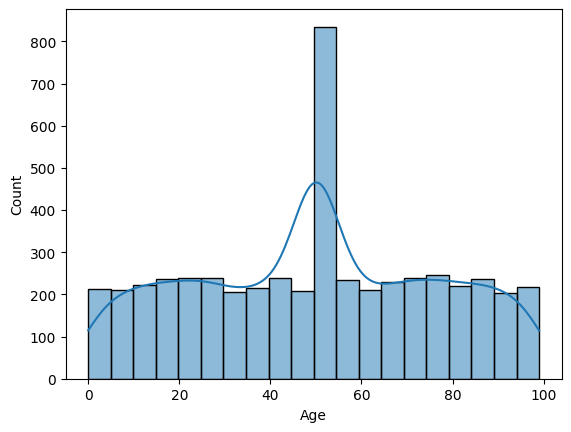

In [12]:
#Answer-# Check distribution of Age
sns.histplot(df['Age'], kde=True)
plt.show()
# Use median (robust against outliers)
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
#ustification: Age datasets often contain outliers or are not perfectly normally distributed. The median is more robust than the mean in such cases.

In [ ]:
#Q3. Handling Missing Treatment Cost
#Scenario:
#Treatment cost is highly skewed due to expensive treatments.
#Task:
#Handle missing Treatment_Cost values
#Choose the correct imputation method and explain why

In [14]:
#Answer - # Check skewness
df['Treatment_Cost'].skew()

# Since Treatment_Cost is highly skewed, use median imputation
median_cost = df['Treatment_Cost'].median()
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(median_cost)

#Justification: As stated in the scenario, the data is "highly skewed". The mean would be heavily influenced by the high-cost outliers, whereas the median provides a more representative "typical" cost

In [ ]:
#Q4. Duplicate Patient Records
#Scenario:
#Some patient records were entered multiple times.
#Task:
#Identify duplicate rows
#Remove duplicates
#Compare dataset size before and after

In [15]:
#Answer - # Size before
initial_size = df.shape[0]

# Identify duplicates
duplicates_count = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicates_count}")

# Remove duplicates
df = df.drop_duplicates()

# Size after
final_size = df.shape[0]
print(f"Dataset size before: {initial_size}, After: {final_size}")

Total duplicate rows found: 99
Dataset size before: 5100, After: 5001


In [ ]:
#Q5. Invalid Age Values (Data Quality Check)
#Scenario:
#Some patients have unrealistic age values (e.g., >100 or <0).
#Task:
#Detect such records
#Decide whether to remove or correct them

In [16]:
#Answer - Decision: We will remove records with Age < 0 and correct ages > 100 by capping them at 100, assuming they are valid elderly patients but possibly typo-prone.
# Detect invalid records
invalid_age = df[(df['Age'] < 0) | (df['Age'] > 100)]
print(f"Number of invalid age records: {len(invalid_age)}")

# Correct/Remove
df = df[df['Age'] >= 0] # Remove negative
df.loc[df['Age'] > 100, 'Age'] = 100 # Cap at 100

Number of invalid age records: 0


In [ ]:
#Q6. Outlier Detection (Treatment Cost)
#Scenario:
#Extreme treatment costs are affecting analysis.
#Task:
#Detect outliers using IQR method
#Display number of outliers

In [17]:
#Answer - # Calculate Q1, Q3, and IQR
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Display count
outliers = df[(df['Treatment_Cost'] < lower_bound) | (df['Treatment_Cost'] > upper_bound)]
print(f"Number of Treatment_Cost outliers: {len(outliers)}")

Number of Treatment_Cost outliers: 50


In [ ]:
#Q7. Outlier Treatment
#Scenario:
#The business team wants to retain all records.
#Task:
#Apply capping (Winsorization) on Treatment_Cost
#Use 5th and 95th percentile


In [18]:
#Answer - # Calculate percentiles
p5 = df['Treatment_Cost'].quantile(0.05)
p95 = df['Treatment_Cost'].quantile(0.95)

# Apply capping (Winsorization)
df['Treatment_Cost'] = df['Treatment_Cost'].clip(lower=p5, upper=p95)

In [ ]:
#Q8. Transformation
#Scenario:
#Treatment cost is highly skewed.
#Task:
#Apply log transformation
#Create a new column
#Compare before vs after distribution

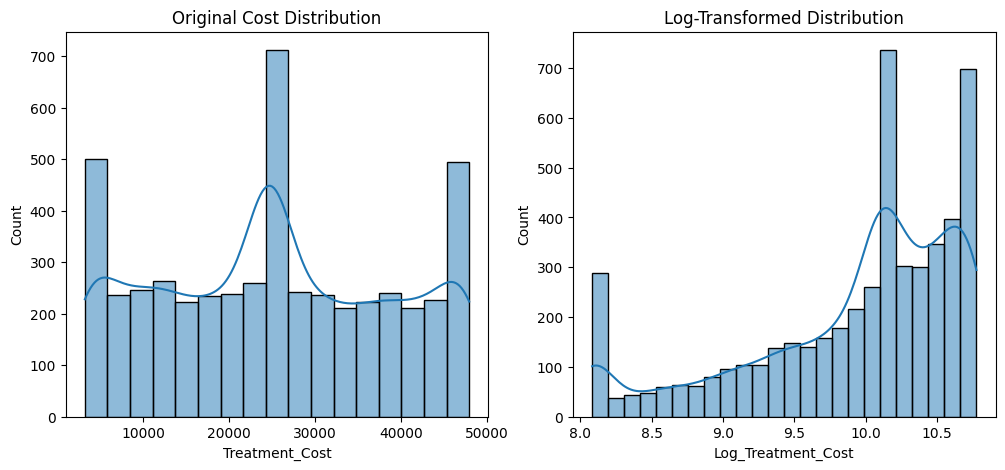

In [19]:
#Answer - # Create new column for log transformation
# Adding 1 to avoid log(0) if any cost is 0
df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost'])

# Visualize Before vs After
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Treatment_Cost'], kde=True).set_title('Original Cost Distribution')

plt.subplot(1, 2, 2)
sns.histplot(df['Log_Treatment_Cost'], kde=True).set_title('Log-Transformed Distribution')
plt.show()

In [ ]:
#Q9. Time-Based Missing Handling
#Scenario:
#Admission dates should follow a logical sequence.
#Task:
#Sort data by Admission_Date
#Apply forward fill or backward fill where appropriate
#Justify your choice

In [20]:
#Answer - # Convert to datetime and sort
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
df = df.sort_values(by='Admission_Date')

# Apply forward fill
df = df.ffill()

# Check for remaining nulls (use bfill for anything at the start)
df = df.bfill()
print("Final check for missing values:")
print(df.isnull().sum())

Final check for missing values:
Patient_ID            0
Age                   0
Gender                0
City                  0
Diagnosis             0
Hospital_Visits       0
Treatment_Cost        0
Insurance_Coverage    0
Admission_Date        0
Log_Treatment_Cost    0
dtype: int64
